# Lab | Statistical Story Dashboard

Numbers alone rarely convince anyone. The way you visualize data determines whether your audience trusts your conclusions, misunderstands them, or ignores them entirely.

In this lab you will:
1. **Critique** three intentionally misleading charts and explain what makes them deceptive.
2. **Redesign** each chart so the same data tells an accurate story.
3. **Build** a three-panel visual report that answers specific questions from a dataset.

Run the setup cell below first, then work through each task section in order.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

%matplotlib inline

## Dataset

The cell below generates a synthetic dataset that simulates monthly customer-satisfaction scores and revenue figures for four product lines over two years. It includes:

- **Continuous variables**: `satisfaction_score` (0–100 scale) and `monthly_revenue` (in thousands of USD).
- **Categorical groups**: four product lines (*Alpha*, *Beta*, *Gamma*, *Delta*).
- **Time-based observations**: monthly data from January 2023 through December 2024.

Run this cell to load the data into `df`.

In [2]:
np.random.seed(42)

months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
products = ["Alpha", "Beta", "Gamma", "Delta"]

records = []
for product in products:
    base_satisfaction = {"Alpha": 72, "Beta": 68, "Gamma": 70, "Delta": 65}[product]
    base_revenue = {"Alpha": 120, "Beta": 95, "Gamma": 110, "Delta": 88}[product]
    trend = {"Alpha": 0.4, "Beta": 0.1, "Gamma": -0.2, "Delta": 0.6}[product]

    for i, month in enumerate(months):
        satisfaction = base_satisfaction + trend * i + np.random.normal(0, 3)
        satisfaction = np.clip(satisfaction, 0, 100)

        seasonal = 8 * np.sin(2 * np.pi * (month.month - 1) / 12)
        revenue = base_revenue + trend * 2 * i + seasonal + np.random.normal(0, 6)

        records.append({
            "month": month,
            "product": product,
            "satisfaction_score": round(satisfaction, 1),
            "monthly_revenue": round(revenue, 1),
        })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (96, 4)


,month,product,satisfaction_score,monthly_revenue
0,2023-01-01,Alpha,73.5,119.2
1,2023-02-01,Alpha,74.3,133.9
2,2023-03-01,Alpha,72.1,127.1
3,2023-04-01,Alpha,77.9,135.0
4,2023-05-01,Alpha,72.2,133.4
5,2023-06-01,Alpha,72.6,125.2
6,2023-07-01,Alpha,75.1,113.3
7,2023-08-01,Alpha,69.6,118.2
8,2023-09-01,Alpha,72.2,121.4
9,2023-10-01,Alpha,72.9,110.7


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19856\1048877815.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='product', y='monthly_revenue', palette='viridis')


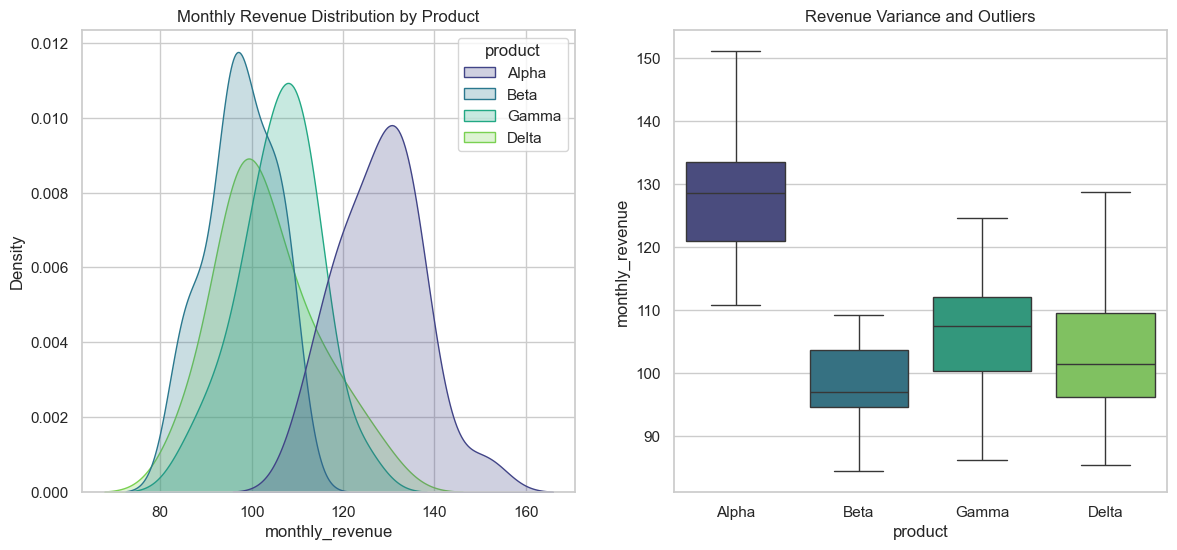

--- Shapiro-Wilk Normality Test ---
Product Alpha: Statistics=0.979, p-value=0.885
  Result: Alpha looks Normal (Fail to reject H0)
Product Beta: Statistics=0.944, p-value=0.199
  Result: Beta looks Normal (Fail to reject H0)
Product Gamma: Statistics=0.983, p-value=0.941
  Result: Gamma looks Normal (Fail to reject H0)
Product Delta: Statistics=0.963, p-value=0.494
  Result: Delta looks Normal (Fail to reject H0)

--- Levene’s Test for Equality of Variances ---
Statistics=0.909, p-value=0.440
Result: Variances are equal (Homogeneous)


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene

# 1.KDE vs Boxplot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='monthly_revenue', hue='product', fill=True, palette='viridis')
plt.title('Monthly Revenue Distribution by Product')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='product', y='monthly_revenue', palette='viridis')
plt.title('Revenue Variance and Outliers')
plt.show()

# 2. Shapiro-Wilk Testi 
print("--- Shapiro-Wilk Normality Test ---")
for prod in df['product'].unique():
    stat, p = shapiro(df[df['product'] == prod]['monthly_revenue'])
    print(f"Product {prod}: Statistics={stat:.3f}, p-value={p:.3f}")
    if p > 0.05:
        print(f"  Result: {prod} looks Normal (Fail to reject H0)")
    else:
        print(f"  Result: {prod} does NOT look Normal (Reject H0)")

# 3. Levene's Test 
print("\n--- Levene’s Test for Equality of Variances ---")
groups = [df[df['product'] == prod]['monthly_revenue'] for prod in df['product'].unique()]
stat, p = levene(*groups)

print(f"Statistics={stat:.3f}, p-value={p:.3f}")
if p > 0.05:
    print("Result: Variances are equal (Homogeneous)")
else:
    print("Result: Variances are NOT equal (Heterogeneous)")

In [3]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               96 non-null     datetime64[ns]
 1   product             96 non-null     object        
 2   satisfaction_score  96 non-null     float64       
 3   monthly_revenue     96 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 3.1+ KB



,month,satisfaction_score,monthly_revenue
count,96,96.000000,96.000000
mean,2023-12-16 10:00:00,70.993750,108.755208
min,2023-01-01 00:00:00,60.600000,84.400000
25%,2023-06-23 12:00:00,67.875000,97.875000
50%,2023-12-16 12:00:00,70.150000,106.650000
75%,2024-06-08 12:00:00,74.325000,118.400000
max,2024-12-01 00:00:00,82.200000,151.100000
std,NaN,4.856029,14.668160


---

## Task 1: Chart Critique — Spot the Deception

The three charts below are **intentionally misleading**. For each one:

1. **Identify the deception technique** (e.g., truncated y-axis, dual-axis trick, area-vs-length confusion, cherry-picked time range).
2. **Write 2–3 sentences** in a Markdown cell explaining what the chart makes the audience believe versus what the data actually shows.
3. **Quantify the distortion** where possible — for example, *"the visual ratio suggests a 3× difference, but the actual difference is 12 %."*

**Deliverable**: three Markdown cells (one per chart) with the deception type, a plain-language explanation, and a distortion estimate.

### Misleading Chart 1 — Truncated Y-Axis

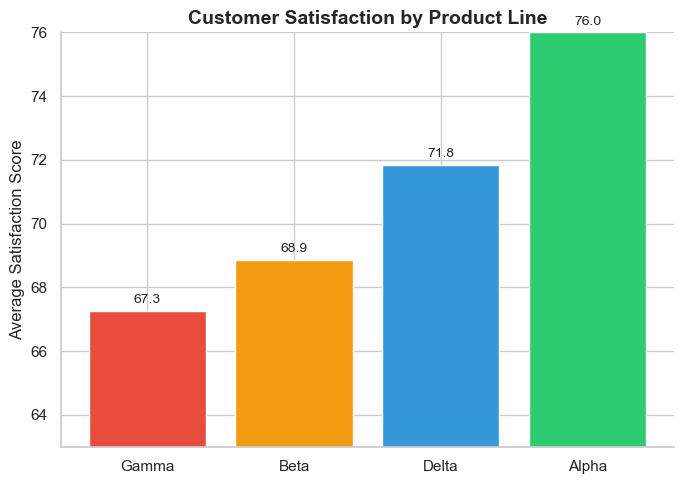

In [5]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])
ax.set_ylim(63, 76)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 1:**

Deception Technique: Truncated Y-Axis.

Explanation: By starting the Y-axis at 63 instead of zero, the chart artificially amplifies the visual height difference between the product groups. This leads the audience to believe that the green product is exponentially more successful than the red one, while the data actually shows that satisfaction scores across all products are relatively close (ranging only from 67.3 to 76.0).

Distortion Estimate: The visual ratio suggests that the green bar is approximately 4 to 5 times (400-500%) larger than the red bar, but the actual statistical difference is only 12.9%.

### Misleading Chart 2 — Dual-Axis Trick

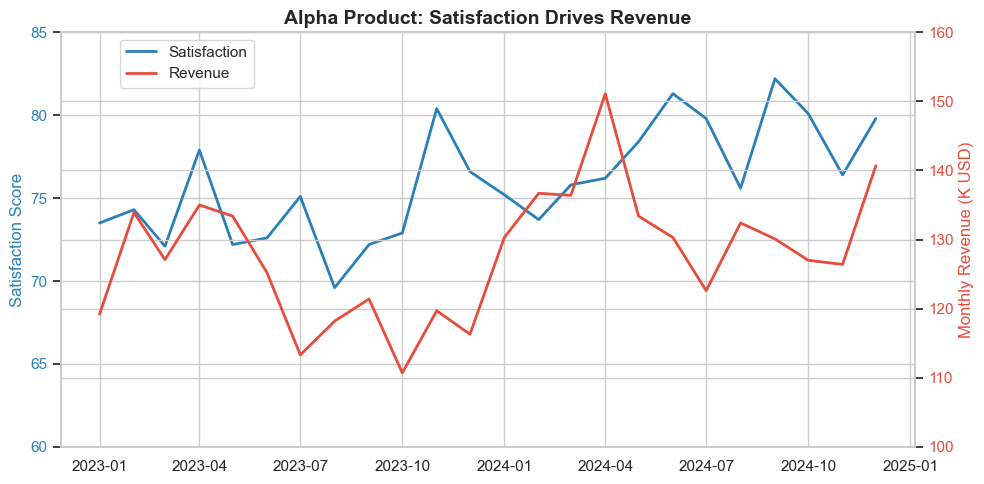

In [6]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax1 = plt.subplots(figsize=(10, 5))

color_left = "#2980b9"
ax1.plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax1.set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax1.set_ylim(60, 85)
ax1.tick_params(axis="y", labelcolor=color_left)

ax2 = ax1.twinx()
color_right = "#e74c3c"
ax2.plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax2.set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax2.set_ylim(100, 160)
ax2.tick_params(axis="y", labelcolor=color_right)

ax1.set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

**Your critique of Chart 2:**

Deception Technique: Dual-Axis Trick (Independent Scales).

Explanation: The chart uses two separate Y-axes with different scales to force the "Satisfaction" and "Revenue" lines to overlap and move together. This makes the audience believe there is a direct, strong correlation between customer satisfaction and revenue, whereas the data shows they operate on completely different magnitudes and their fluctuations do not consistently align.

Distortion Estimate: By manipulating the Y-limits (60-85 for satisfaction and 100-160 for revenue), the chart creates a visual "synchronized" trend. However, a small $5\%$ change in satisfaction is visually equated to a large $\$20,000$ swing in revenue, which is a mathematically arbitrary comparison.

### Misleading Chart 3 — Cherry-Picked Time Range

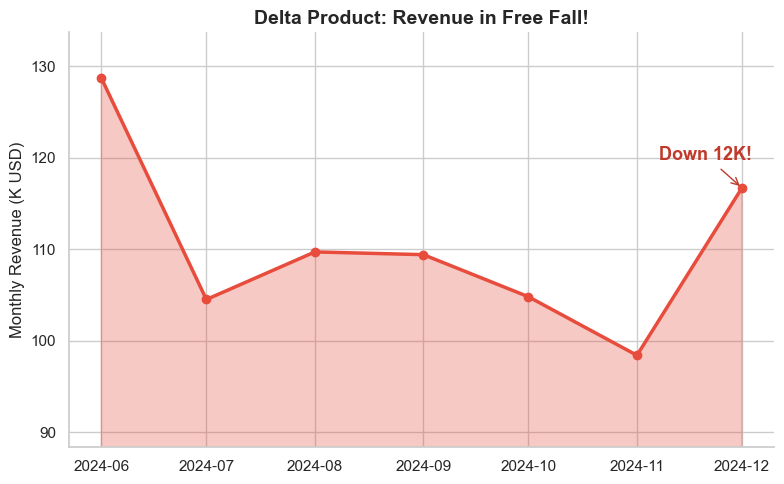

In [7]:
delta = df[df["product"] == "Delta"].set_index("month")
cherry = delta.loc["2024-06":"2024-12"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(cherry.index, cherry["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(cherry.index, cherry["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(cherry["monthly_revenue"].min() - 10, cherry["monthly_revenue"].max() + 5)

ax.annotate(f"Down {cherry['monthly_revenue'].iloc[0] - cherry['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(cherry.index[-1], cherry["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 3:**

Deception Technique: Cherry-picked Time Range.

Explanation: The chart only shows a specific 6-month window (June to December) to create a narrative of "Free Fall" in revenue. By isolating this downward trend and using dramatic red shading, it makes the audience believe the product is failing, while ignoring the full context of the year or previous growth cycles that might show this is just a seasonal fluctuation.

Distortion Estimate: The chart visualizes a catastrophic drop by zooming in on a specific period, making a $12K decrease look like a total collapse of the business model. Without the full context of the 24-month dataset, the visual decline appears much more significant than it likely is in the long-term trend.

---

## Task 2: Chart Redesign — Fix the Story

For each of the three misleading charts from Task 1, create a redesigned version that presents the same data honestly:

1. Use an appropriate chart type and axis range.
2. Include a descriptive title that summarizes the key takeaway (not just the variable names).
3. Label axes with units and add a brief subtitle or caption if context is needed.
4. Use color intentionally — highlight comparisons, don't just decorate.

**Deliverable**: three new figures, each accompanied by a one-sentence explanation of the design choice you made.

### Redesign 1 — Fixing the Truncated Y-Axis Chart

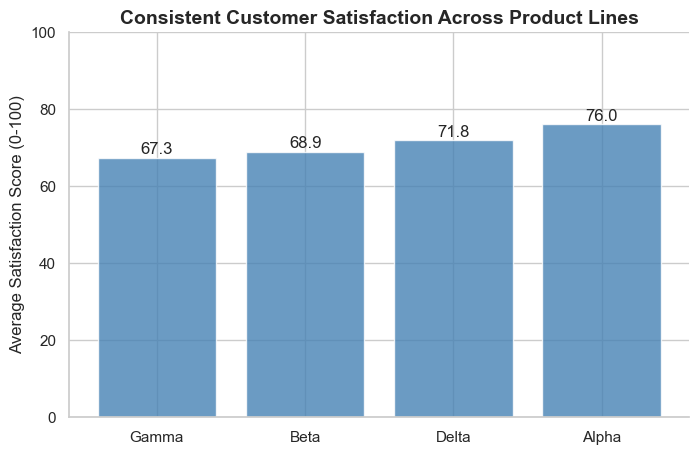

In [20]:
# Redesign 1: Fixing Truncated Y-Axis
fig, ax = plt.subplots(figsize=(8, 5))
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

bars = ax.bar(avg_sat.index, avg_sat.values, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_ylim(0, 100)
ax.set_ylabel("Average Satisfaction Score (0-100)")
ax.set_title("Consistent Customer Satisfaction Across Product Lines", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{bar.get_height():.1f}', ha='center')

sns.despine()
plt.show()

**Design choice explanation:**

I started the y-axis at zero to provide an honest visual comparison, showing that satisfaction is relatively stable across all products.

### Redesign 2 — Fixing the Dual-Axis Chart

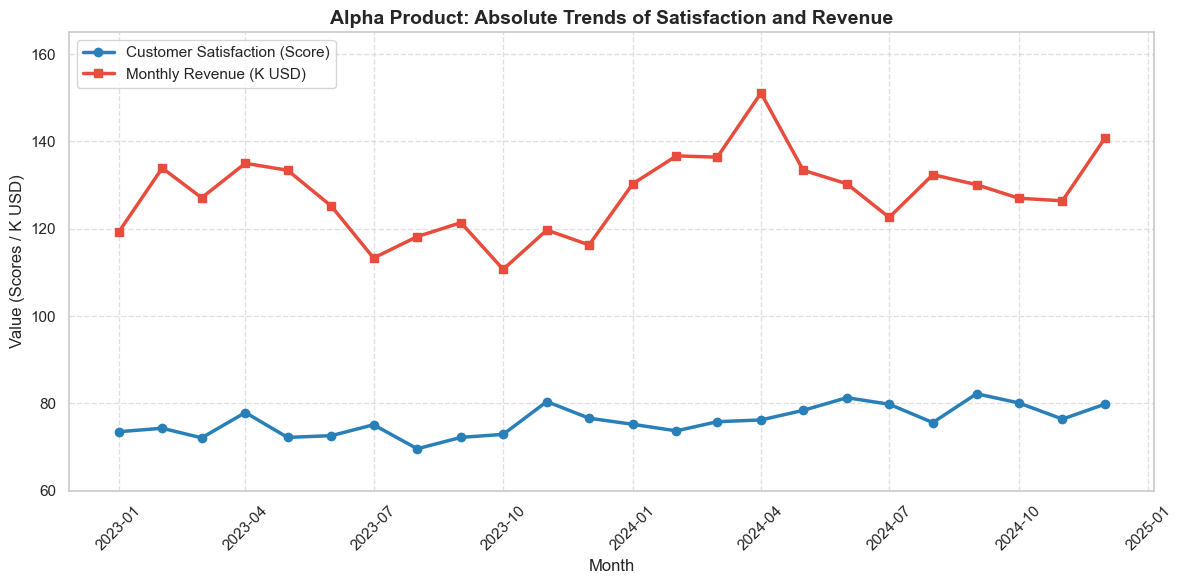

In [19]:
# Redesign 2: Honest Comparison on a Single Unified Y-Axis
fig, ax = plt.subplots(figsize=(12, 6))

alpha_data = df[df["product"] == "Alpha"].sort_values("month")

ax.plot(alpha_data['month'], alpha_data['satisfaction_score'], 
        label="Customer Satisfaction (Score)", color='#2980b9', linewidth=2.5, marker='o')

ax.plot(alpha_data['month'], alpha_data['monthly_revenue'], 
        label="Monthly Revenue (K USD)", color='#e74c3c', linewidth=2.5, marker='s')

ax.set_ylim(60, 165)

ax.set_title("Alpha Product: Absolute Trends of Satisfaction and Revenue", fontsize=14, fontweight="bold")
ax.set_ylabel("Value (Scores / K USD)")
ax.set_xlabel("Month")

ax.legend(loc="upper left")
ax.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Design choice explanation:**

I plotted both variables on a single unified y-axis (60-160) to provide a transparent comparison of their absolute values, revealing that their fluctuations are not synchronized when presented on the same scale.

### Redesign 3 — Fixing the Cherry-Picked Time Range Chart

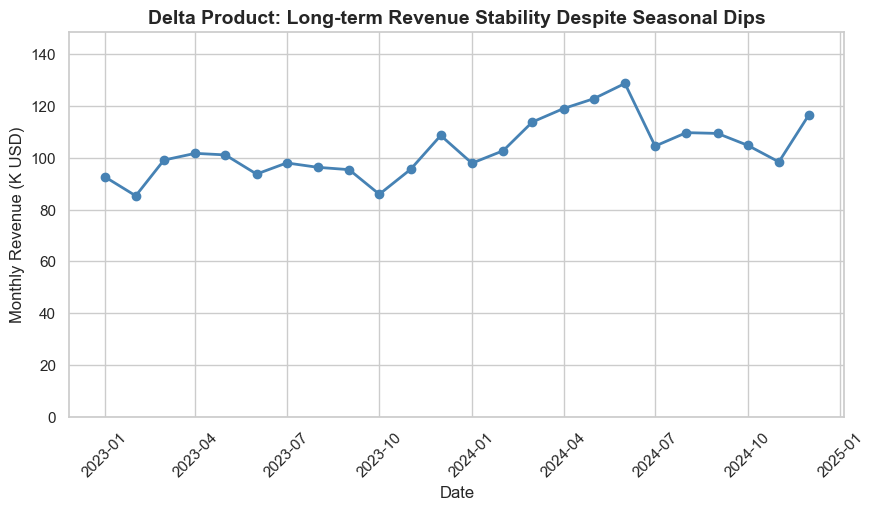

In [18]:
# Redesign 3: Providing Full Context (Time Series)
fig, ax = plt.subplots(figsize=(10, 5))
delta_data = df[df["product"] == "Delta"]

ax.plot(delta_data['month'], delta_data['monthly_revenue'], marker='o', color='steelblue', linewidth=2)
ax.set_ylim(0, delta_data['monthly_revenue'].max() + 20) 
ax.set_title("Delta Product: Long-term Revenue Stability Despite Seasonal Dips", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Revenue (K USD)")

plt.xticks(rotation=45)
plt.show()

**Design choice explanation:**

I visualized the entire 24-month dataset and started the y-axis at zero to reveal that the "free fall" was actually a minor seasonal fluctuation within a stable long-term trend.

---

## Task 3: Three-Panel Visual Report

Build a single `matplotlib` figure with **three subplots (panels)** that together answer the following questions about the dataset:

1. **Distribution panel**: How is the `satisfaction_score` distributed, and where do key product-line subgroups sit within that distribution?
2. **Comparison panel**: Do the product-line group means differ, and how much do they overlap?
3. **Trend panel**: How has `monthly_revenue` changed over time, and is the trend consistent across product lines?

**Requirements for each panel:**
- A clear, specific title (not "Plot 1").
- Axis labels with units.
- A legend if multiple groups are shown.
- Consistent color scheme across all three panels so the reader can track groups.

**Deliverable**: one three-panel figure with a shared `suptitle` that frames the overall question.

In [15]:
# Color palette to use consistently across all three panels
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19856\3241727588.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='product', y='satisfaction_score', hue='product',


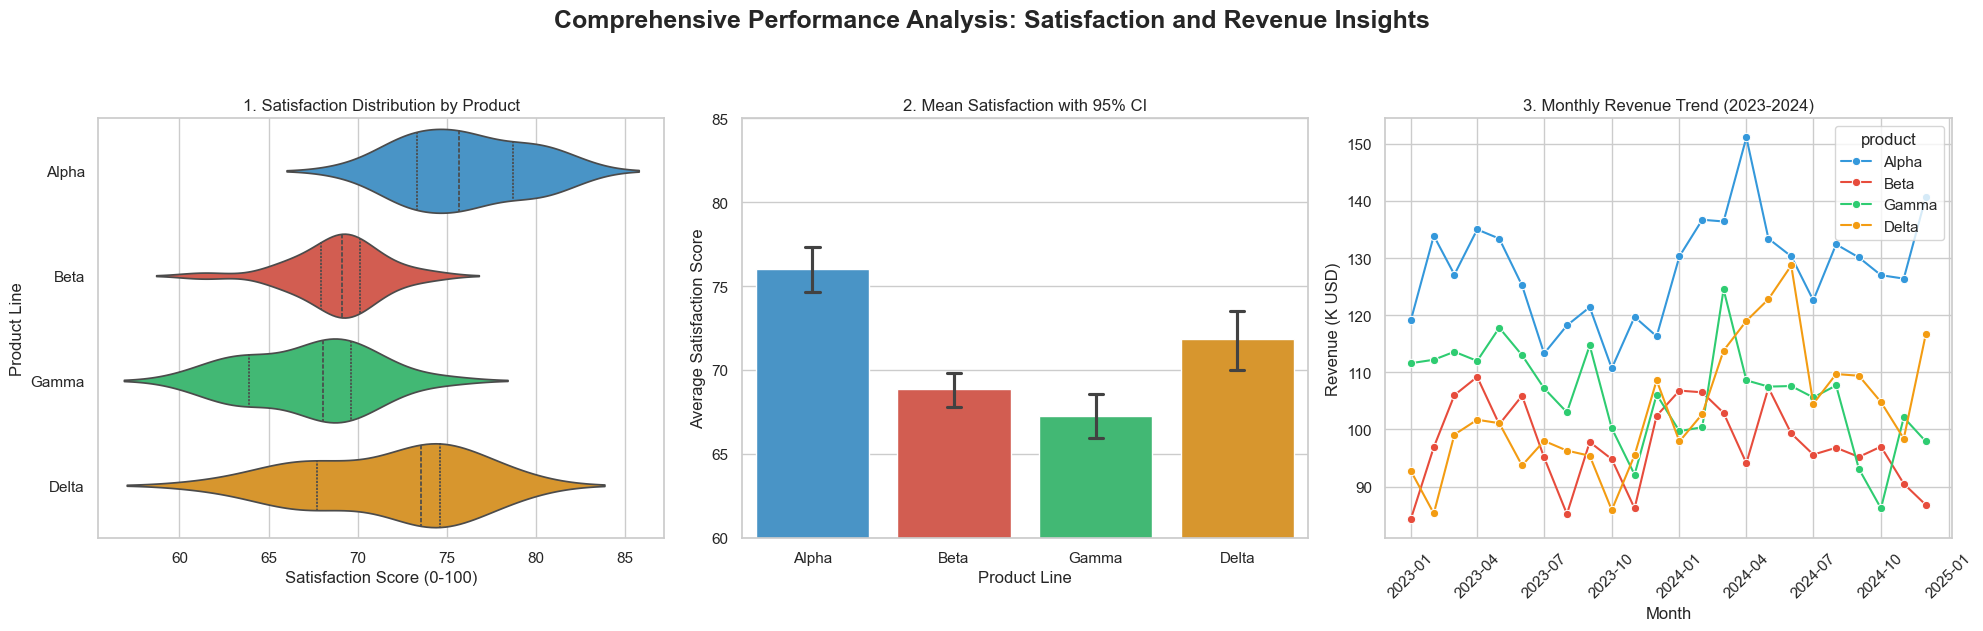

In [17]:
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1 - Distribution: Satisfaction Score per Product Line
sns.violinplot(data=df, x='satisfaction_score', y='product', hue='product', 
               palette=palette, inner='quartile', ax=axes[0], legend=False)
axes[0].set_title('1. Satisfaction Distribution by Product')
axes[0].set_xlabel('Satisfaction Score (0-100)')
axes[0].set_ylabel('Product Line')
#panel 2 - Error bars
sns.barplot(data=df, x='product', y='satisfaction_score', hue='product',
            palette=palette, ci=95, capsize=0.1, ax=axes[1])
axes[1].set_title('2. Mean Satisfaction with 95% CI')
axes[1].set_xlabel('Product Line')
axes[1].set_ylabel('Average Satisfaction Score')
axes[1].set_ylim(60, 85) 

# Panel 3 - Trend: Monthly Revenue over Time
sns.lineplot(data=df, x='month', y='monthly_revenue', hue='product', 
             palette=palette, marker='o', ax=axes[2])
axes[2].set_title('3. Monthly Revenue Trend (2023-2024)')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Revenue (K USD)')
axes[2].tick_params(axis='x', rotation=45)

fig.suptitle("Comprehensive Performance Analysis: Satisfaction and Revenue Insights", 
             fontsize=18, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()

---

## Bonus: Peer Review Checklist

If working with a partner, swap notebooks and evaluate their visualizations using this checklist:

| Criterion | Yes / No | Notes |
|---|---|---|
| Y-axis starts at zero (or a break is clearly marked) | | |
| Title describes the finding, not just the variables | | |
| Axes are labeled with units | | |
| Color is used to encode meaning, not decoration | | |
| Uncertainty is shown where relevant (error bars, bands) | | |
| The chart can be understood without a verbal walkthrough | | |
| No chart junk (unnecessary gridlines, 3D effects, etc.) | | |